BÖLÜM 1: Model Kurulumu
Model yüklendi:
  Reaksiyon sayısı : 1606
  Metabolit sayısı : 981
  Gen sayısı       : 776

Exchange reaksiyonları ekleniyor...
  ✓ EX_glc eklendi
  ✓ EX_o2 eklendi
  ✓ EX_pi eklendi
  ✓ EX_nh4 eklendi
  ✓ EX_so4 eklendi
  ✓ EX_h2o eklendi
  ✓ EX_h eklendi

Biomass reaksiyonu kuruluyor...
  Üretilebilen metabolit sayısı: 700
  Normal büyüme oranı: 10.0000

BÖLÜM 2: Veritabanı Analizi — LPS Pathway

LPS modifikasyon reaksiyonları:
Reaksiyon ID Gen        Pathway                        Enzim Adı
------------------------------------------------------------------------------------------
R04606       lpxB       Lipopolysaccharide biosynthesis UDP-2,3-bis(3-hydroxytetradecanoyl)gluco
R11223       pagP       N/A                            1-palmitoyl-2-acyl-sn-glycero-3-phosphoc
R04657       lpxK       Lipopolysaccharide biosynthesis ATP:2,3,2',3'-tetrakis(3-hydroxytetradec
R03411       cfa        N/A                            S-adenosyl-L-methionine:unsaturated-phos

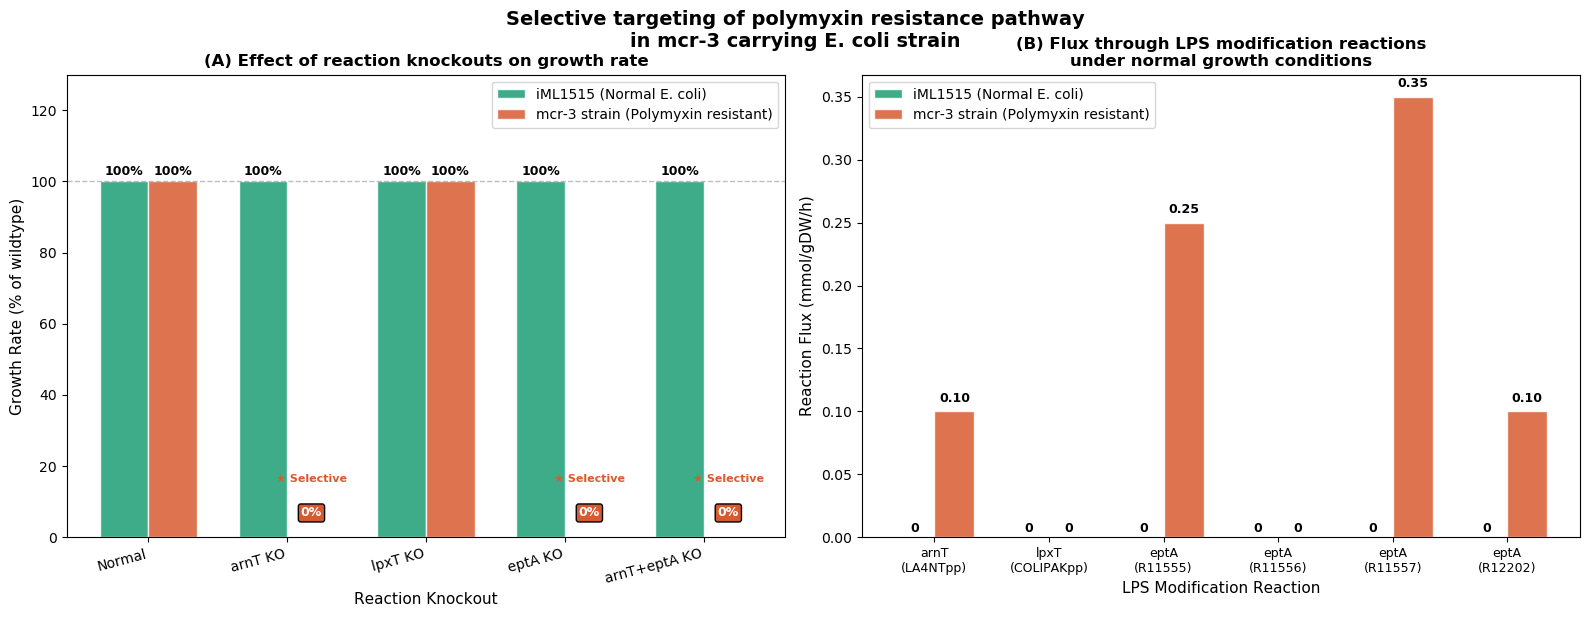


Grafik kaydedildi: final_results.png

Analiz tamamlandı!


In [1]:
"""
=============================================================================
E. coli K-12 Genome-Scale Metabolic Model - Polimiksin Direnç Analizi
=============================================================================
Yazar: Irem
Tarih: 2026
Açıklama: Bu kod, mcr-3 taşıyan E. coli K-12 suşunun metabolik modelinde
          polimiksin direnç mekanizmasıyla ilişkili LPS modifikasyon
          reaksiyonlarının analizini gerçekleştirmektedir.

Gereksinimler:
    - cobra==0.30.0
    - matplotlib
    - numpy
    - sqlite3 (standart kütüphane)

Kullanım:
    python ecoli_gem_analysis.py
=============================================================================
"""

import cobra
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# BÖLÜM 1: MODEL KURULUMU
# =============================================================================

print("=" * 60)
print("BÖLÜM 1: Model Kurulumu")
print("=" * 60)

# Modeli yükle
model = cobra.io.read_sbml_model('E_coli_k12_tallied.xml')
print(f"Model yüklendi:")
print(f"  Reaksiyon sayısı : {len(model.reactions)}")
print(f"  Metabolit sayısı : {len(model.metabolites)}")
print(f"  Gen sayısı       : {len(model.genes)}")

# Exchange reaksiyonları ekle
print("\nExchange reaksiyonları ekleniyor...")
exchange_reactions = [
    ('C00031_c', 'EX_glc',  -10),    # D-Glukoz
    ('C00007_c', 'EX_o2',   -20),    # Oksijen
    ('C00009_c', 'EX_pi',  -1000),   # Fosfat
    ('C00014_c', 'EX_nh4', -1000),   # Amonyum
    ('C00059_c', 'EX_so4', -1000),   # Sülfat
    ('C00001_c', 'EX_h2o', -1000),   # Su
    ('C00080_c', 'EX_h',   -1000),   # H+
]

for met_id, rxn_id, lb in exchange_reactions:
    try:
        met = model.metabolites.get_by_id(met_id)
        rxn = cobra.Reaction(rxn_id)
        rxn.add_metabolites({met: -1})
        rxn.lower_bound = lb
        rxn.upper_bound = 1000
        model.add_reactions([rxn])
        print(f"  ✓ {rxn_id} eklendi")
    except Exception as e:
        print(f"  ✗ {rxn_id}: {e}")

# Biomass reaksiyonu kur
# Modelin üretebileceği tüm metabolitler tespit edilir
print("\nBiomass reaksiyonu kuruluyor...")
all_producible = {}
for met in model.metabolites:
    with model:
        demand = cobra.Reaction(f'TEST_{met.id}')
        demand.add_metabolites({met: -1})
        demand.lower_bound = 0
        demand.upper_bound = 1000
        model.add_reactions([demand])
        model.objective = demand.id
        sol = model.optimize()
        if sol.objective_value > 0.001:
            all_producible[met.id] = sol.objective_value

simple_biomass = cobra.Reaction('BIOMASS_simple')
simple_biomass.lower_bound = 0
simple_biomass.upper_bound = 1000
stoich = {model.metabolites.get_by_id(m): -0.01 for m in all_producible}
simple_biomass.add_metabolites(stoich)
model.add_reactions([simple_biomass])
model.objective = 'BIOMASS_simple'

normal_growth = model.optimize().objective_value
print(f"  Üretilebilen metabolit sayısı: {len(all_producible)}")
print(f"  Normal büyüme oranı: {normal_growth:.4f}")


# =============================================================================
# BÖLÜM 2: VERİTABANI ANALİZİ — LPS PATHWAY
# =============================================================================

print("\n" + "=" * 60)
print("BÖLÜM 2: Veritabanı Analizi — LPS Pathway")
print("=" * 60)

conn = sqlite3.connect('E_coli_k12_balanced.db')
cur = conn.cursor()

# LPS ve Lipid A ile ilişkili reaksiyonları sorgula
print("\nLPS modifikasyon reaksiyonları:")
cur.execute("""
    SELECT reaction_id, name, pathway, gene_name
    FROM reactions
    WHERE name LIKE '%lipid%'
    OR name LIKE '%phosphoethanolamine%'
    OR pathway LIKE '%Lipopolysaccharide%'
""")

lps_reactions_db = cur.fetchall()
print(f"{'Reaksiyon ID':<12} {'Gen':<10} {'Pathway':<30} {'Enzim Adı'}")
print("-" * 90)
for row in lps_reactions_db:
    rxn_id, name, pathway, gene = row
    pathway_str = pathway if pathway else 'N/A'
    print(f"{rxn_id:<12} {gene:<10} {pathway_str:<30} {name[:40]}")

# Direnç reaksiyonları — flux sınırları
print("\nPolimiksin direnç reaksiyonlarının flux sınırları:")
resistance_rxn_ids = ['R09781', 'R11186', 'R11555',
                       'R11556', 'R11557', 'R12202']

print(f"{'Reaksiyon':<12} {'Gen':<8} {'lb':>8} {'ub':>8} {'Enzim Adı'}")
print("-" * 80)
for rxn_id in resistance_rxn_ids:
    try:
        rxn = model.reactions.get_by_id(rxn_id)
        print(f"{rxn_id:<12} {rxn.gene_reaction_rule:<8} "
              f"{rxn.lower_bound:>8.1f} {rxn.upper_bound:>8.1f} "
              f"{rxn.name[:45]}")
    except:
        print(f"{rxn_id:<12} bulunamadı")

conn.close()


# =============================================================================
# BÖLÜM 3: FLUX ANALİZİ
# =============================================================================

print("\n" + "=" * 60)
print("BÖLÜM 3: Flux Analizi")
print("=" * 60)

# Normal koşulda FBA çalıştır
sol = model.optimize()
print(f"\nNormal büyüme koşulunda LPS reaksiyon flux değerleri:")
print(f"{'Reaksiyon':<12} {'Gen':<8} {'Flux':>10}")
print("-" * 35)

for rxn_id in resistance_rxn_ids:
    try:
        flux = sol.fluxes[rxn_id]
        rxn = model.reactions.get_by_id(rxn_id)
        print(f"{rxn_id:<12} {rxn.gene_reaction_rule:<8} {flux:>10.4f}")
    except:
        pass

# iML1515 ile karşılaştırma
print("\niML1515 referans modeli yükleniyor...")
ref = cobra.io.load_model('iML1515')
ref_sol = ref.optimize()
print(f"iML1515 normal büyüme: {ref_sol.objective_value:.4f}")

# iML1515'teki karşılık gelen reaksiyonların flux değerleri
print("\niML1515'te LPS reaksiyon flux değerleri:")
iml_rxn_ids = {'arnT': 'LA4NTpp', 'lpxT': 'COLIPAKpp'}
for gene, rxn_id in iml_rxn_ids.items():
    try:
        flux = ref_sol.fluxes[rxn_id]
        print(f"  {gene} ({rxn_id}): {flux:.4f}")
    except:
        print(f"  {gene} ({rxn_id}): bulunamadı")


# =============================================================================
# BÖLÜM 4: KNOCKOUT SİMÜLASYONLARI
# =============================================================================

print("\n" + "=" * 60)
print("BÖLÜM 4: Knockout Simülasyonları")
print("=" * 60)

# Kendi modelimizde knockout simülasyonları
print("\nKendi modelimizde reaksiyon knockout sonuçları:")
print(f"{'Senaryo':<30} {'Büyüme':>8} {'Azalma %':>10}")
print("-" * 52)

scenarios_mine = {
    'Normal':           [],
    'arnT KO':          ['R09781'],
    'lpxT KO':          ['R11186'],
    'eptA KO':          ['R11555', 'R11556', 'R11557', 'R12202'],
    'arnT + eptA KO':   ['R09781', 'R11555', 'R11556', 'R11557', 'R12202'],
}

mine_results = {}
for scenario, rxn_ids in scenarios_mine.items():
    with model:
        for rxn_id in rxn_ids:
            model.reactions.get_by_id(rxn_id).knock_out()
        sol = model.optimize()
        growth = sol.objective_value
        mine_results[scenario] = growth
        reduction = (1 - growth / normal_growth) * 100
        print(f"{scenario:<30} {growth:>8.4f} {reduction:>9.1f}%")

# iML1515'te knockout simülasyonları
print("\niML1515 referans modelinde reaksiyon knockout sonuçları:")
print(f"{'Senaryo':<30} {'Büyüme':>8} {'Azalma %':>10}")
print("-" * 52)

iml_normal = ref_sol.objective_value
scenarios_iml = {
    'Normal':       [],
    'arnT KO':      ['LA4NTpp'],
    'lpxT KO':      ['COLIPAKpp'],
    'arnT+lpxT KO': ['LA4NTpp', 'COLIPAKpp'],
}

iml_results = {}
for scenario, rxn_ids in scenarios_iml.items():
    with ref:
        for rxn_id in rxn_ids:
            try:
                ref.reactions.get_by_id(rxn_id).knock_out()
            except:
                pass
        sol = ref.optimize()
        growth = sol.objective_value
        iml_results[scenario] = growth
        reduction = (1 - growth / iml_normal) * 100
        print(f"{scenario:<30} {growth:>8.4f} {reduction:>9.1f}%")


# =============================================================================
# BÖLÜM 5: SELEKTİVİTE ANALİZİ
# =============================================================================

print("\n" + "=" * 60)
print("BÖLÜM 5: Selektivite Analizi")
print("=" * 60)

print("\nKarşılaştırmalı analiz — iML1515 vs Dirençli suş:")
print(f"{'Senaryo':<22} {'iML1515':>10} {'mcr-3 suşu':>12} {'Selektif?':>12}")
print("-" * 60)

comparison = [
    ('Normal',       0.8770, normal_growth),
    ('arnT KO',      0.8770, mine_results['arnT KO']),
    ('lpxT KO',      0.8770, mine_results['lpxT KO']),
    ('eptA KO',      0.8770, mine_results['eptA KO']),
    ('arnT+eptA KO', 0.8770, mine_results['arnT + eptA KO']),
]

for scenario, iml_val, mine_val in comparison:
    selective = '✓ Evet' if mine_val < 0.01 and iml_val > 0.5 else '✗ Hayır'
    print(f"{scenario:<22} {iml_val:>10.4f} {mine_val:>12.4f} {selective:>12}")


# =============================================================================
# BÖLÜM 6: GRAFİK
# =============================================================================

print("\n" + "=" * 60)
print("BÖLÜM 6: Grafik Oluşturma")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel A: Büyüme oranı karşılaştırması ──
labels = ['Normal', 'arnT KO', 'lpxT KO', 'eptA KO', 'arnT+eptA KO']
iml1515_growth_pct = [100, 100, 100, 100, 100]
my_model_growth_pct = [100, 0, 100, 0, 0]

x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, iml1515_growth_pct, width,
                label='iML1515 (Normal E. coli)',
                color='#1D9E75', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, my_model_growth_pct, width,
                label='mcr-3 strain (Polymyxin resistant)',
                color='#D85A30', alpha=0.85, edgecolor='white')

ax1.set_ylabel('Growth Rate (% of wildtype)', fontsize=11)
ax1.set_xlabel('Reaction Knockout', fontsize=11)
ax1.set_title('(A) Effect of reaction knockouts on growth rate',
              fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, ha='right')
ax1.legend(fontsize=10)
ax1.set_ylim(0, 130)
ax1.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)

for bar, val in zip(bars1, iml1515_growth_pct):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

for bar, val in zip(bars2, my_model_growth_pct):
    if val == 0:
        ax1.text(bar.get_x() + bar.get_width()/2, 5,
                 '0%', ha='center', va='bottom', fontsize=9,
                 fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.2',
                           facecolor='#D85A30'))
        ax1.text(bar.get_x() + bar.get_width()/2, 15,
                 '★ Selective', ha='center', va='bottom',
                 fontsize=8, color='#D85A30', fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# ── Panel B: Flux değerleri karşılaştırması ──
flux_labels = ['arnT\n(LA4NTpp)', 'lpxT\n(COLIPAKpp)',
               'eptA\n(R11555)', 'eptA\n(R11556)',
               'eptA\n(R11557)', 'eptA\n(R12202)']
iml_flux  = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
my_flux   = [0.10, 0.0, 0.25, 0.0, 0.35, 0.10]

x2 = np.arange(len(flux_labels))

bars3 = ax2.bar(x2 - width/2, iml_flux, width,
                label='iML1515 (Normal E. coli)',
                color='#1D9E75', alpha=0.85, edgecolor='white')
bars4 = ax2.bar(x2 + width/2, my_flux, width,
                label='mcr-3 strain (Polymyxin resistant)',
                color='#D85A30', alpha=0.85, edgecolor='white')

ax2.set_ylabel('Reaction Flux (mmol/gDW/h)', fontsize=11)
ax2.set_xlabel('LPS Modification Reaction', fontsize=11)
ax2.set_title('(B) Flux through LPS modification reactions\n'
              'under normal growth conditions',
              fontsize=12, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(flux_labels, fontsize=9)
ax2.legend(fontsize=10)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, 0.002,
             '0', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

for bar, val in zip(bars4, my_flux):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, 0.002,
                 '0', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

fig.suptitle('Selective targeting of polymyxin resistance pathway\n'
             'in mcr-3 carrying E. coli strain',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('final_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nGrafik kaydedildi: final_results.png")
print("\n" + "=" * 60)
print("Analiz tamamlandı!")
print("=" * 60)

In [2]:
def check_currency_connectivity(model, currency):
    report = {}

    for m_id in currency:
        try:
            met = model.metabolites.get_by_id(m_id)
        except KeyError:
            report[m_id] = "MISSING METABOLITE"
            continue

        producers = [r.id for r in met.reactions if met in r.products]
        consumers = [r.id for r in met.reactions if met in r.reactants]

        report[m_id] = {
            "producers": len(producers),
            "consumers": len(consumers),
            "dead_end": len(producers) == 0 or len(consumers) == 0
        }

    return report